<a href="https://colab.research.google.com/github/magish-gautam/AI-Portfolio/blob/Workshop-2/Regression_assestment_magish_gautam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1) Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

In [3]:
# 2) Load Dataset
data = pd.read_csv("delhi-weather-aqi-2025.csv")
print("Dataset preview:")
print(data.head())

Dataset preview:
     date_ist time_ist     location      lat     lon  temp_c  humidity  \
0  01/01/2025     0:00  Anand Vihar  28.6469  77.316     8.1       100   
1  01/01/2025     1:00  Anand Vihar  28.6469  77.316     7.7       100   
2  01/01/2025     2:00  Anand Vihar  28.6469  77.316     7.5       100   
3  01/01/2025     3:00  Anand Vihar  28.6469  77.316     7.8        99   
4  01/01/2025     4:00  Anand Vihar  28.6469  77.316     7.3       100   

   pressure_mb  windspeed_kph condition_text description  aqi_index  pm2_5  \
0        995.4            2.9   Mainly clear  WMO Code 1        197  185.8   
1        994.7            3.2       Overcast  WMO Code 3        198  174.6   
2        994.3            4.5       Overcast  WMO Code 3        199  164.4   
3        994.1            6.0       Overcast  WMO Code 3        200  156.5   
4        993.8            6.8       Overcast  WMO Code 3        200  149.5   

    pm10    co   no2  
0  188.6  1907  56.7  
1  177.4  1669  44.8  


In [4]:
# 3) Feature Selection
X = data[['temp_c', 'humidity', 'pressure_mb', 'windspeed_kph',
          'pm2_5', 'pm10', 'co', 'no2']]
y = data['aqi_index']

In [5]:
# Drop missing values
X = X.dropna()
y = y[X.index]

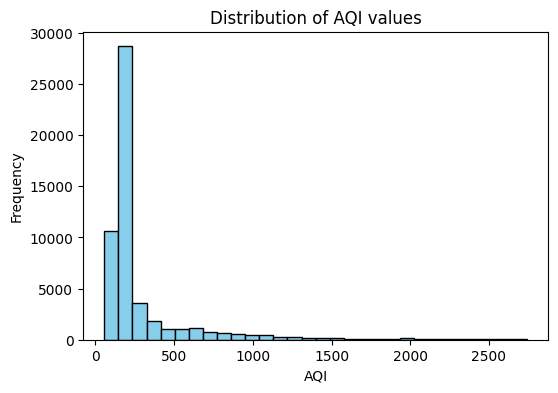

In [6]:
# 4) Exploratory Data Analysis

# Histogram of AQI
plt.figure(figsize=(6,4))
plt.hist(y, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("Distribution of AQI values")
plt.show()

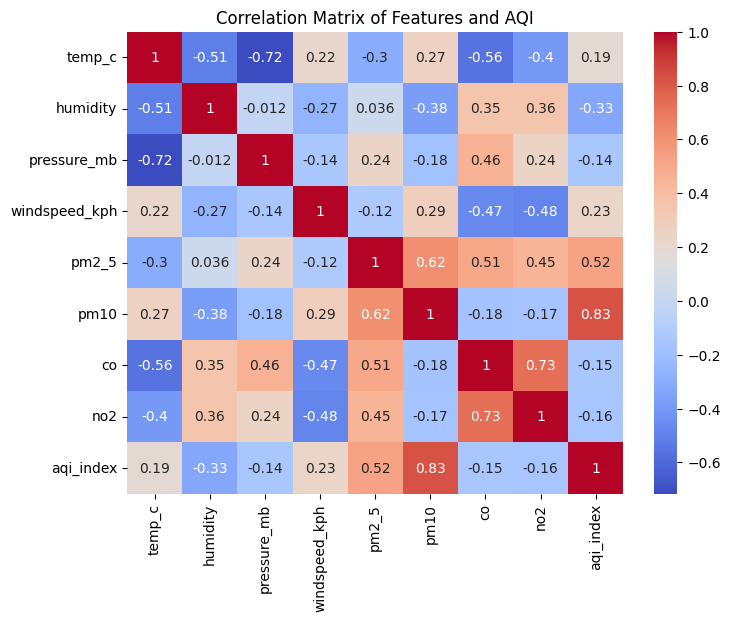

In [7]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(X.join(y).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Features and AQI")
plt.show()

Text(0.5, 1.0, 'PM2.5 vs AQI')

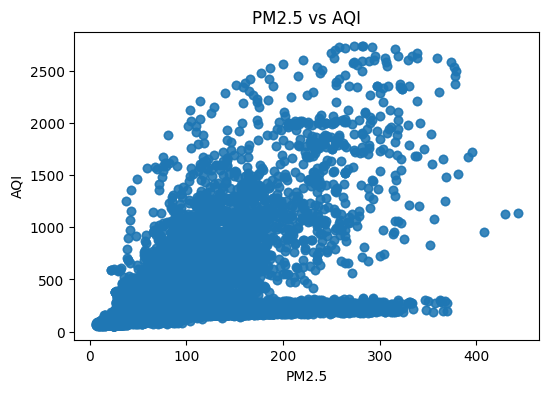

In [8]:
# Scatter plot for PM2.5 vs AQI
plt.figure(figsize=(6,4))
plt.scatter(X['pm2_5'], y, alpha=0.5)
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.title("PM2.5 vs AQI")

In [9]:
# 5) Feature Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [10]:
# 6) Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [17]:
# 7) Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

In [12]:
# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)


Linear Regression Results:
MAE: 93.22106466609425
MSE: 31869.824264663097
R2 Score: 0.7027159824097285


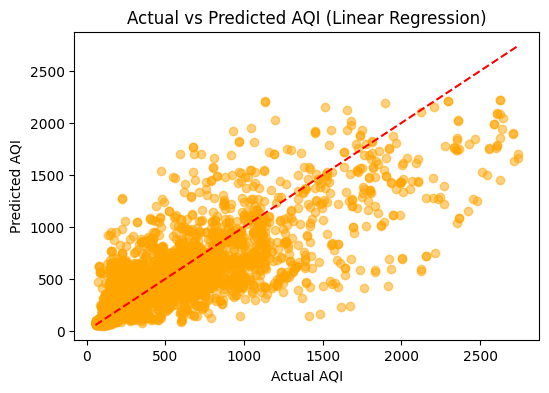

In [13]:
# 8) Actual vs Predicted Plot
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.5, color='orange')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Linear Regression)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [18]:
# 9) Save Predictions
results = pd.DataFrame({
    "Actual AQI": y_test,
    "Predicted AQI": y_pred
})
results.to_csv("regression_results.csv", index=False)
print("Results saved to regression_results.csv")

Results saved to regression_results.csv


In [15]:
# 10) Optional Feature Selection with RFE
rfe = RFE(lr_model, n_features_to_select=5)
rfe.fit(X_scaled, y)
selected_features = X.columns[rfe.support_]
print("Selected Features:", list(selected_features))

Selected Features: ['temp_c', 'humidity', 'pressure_mb', 'pm2_5', 'pm10']


In [16]:
# 11. Optional Advanced Model: Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest R2 Score:", r2_rf)

Random Forest R2 Score: 0.9201900599261329
